In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# =========================================================
# LOAD MODELS
# =========================================================

seg_model = YOLO(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\notebooks\training\runs\segment\train-10\weights\best.pt"
)

cls_model = load_model(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\models\classification\efficientnet_finetuned.keras"
)

# =========================================================
# CLASS LABELS
# =========================================================

grade_labels = [
    "Mild",
    "Moderate",
    "Severe"
]

# =========================================================
# MAIN FUNCTION
# =========================================================

def analyze_cancer(image_path, conf=0.5, imgsz=512):

    # =====================================================
    # READ IMAGE
    # =====================================================

    image = cv2.imread(image_path)

    if image is None:
        print("Invalid image path")
        return

    original = image.copy()

    # =====================================================
    # RUN SEGMENTATION
    # =====================================================

    results = seg_model.predict(
        source=image_path,
        conf=conf,
        imgsz=imgsz,
        verbose=False
    )

    result = results[0]

    # =====================================================
    # CHECK DETECTION
    # =====================================================

    if result.masks is None:

        print("\n========== FINAL REPORT ==========")
        print("Cancer Detected : NO")
        print("==================================")

        plt.figure(figsize=(5,5))

        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))

        plt.axis("off")

        plt.title("No Cancer Detected")

        plt.show()

        return

    # =====================================================
    # GET FIRST BOX
    # =====================================================

    boxes = result.boxes.xyxy.cpu().numpy()

    x1, y1, x2, y2 = boxes[0].astype(int)

    # =====================================================
    # CROP LESION
    # =====================================================

    crop = original[y1:y2, x1:x2]

    # =====================================================
    # PREPROCESS FOR CLASSIFICATION
    # =====================================================

    cls_img = cv2.resize(crop, (300,300))

    cls_img = cv2.cvtColor(cls_img, cv2.COLOR_BGR2RGB)

    cls_img = img_to_array(cls_img)

    cls_img = cls_img / 255.0

    cls_img = np.expand_dims(cls_img, axis=0)

    # =====================================================
    # PREDICT GRADE
    # =====================================================

    pred = cls_model.predict(cls_img, verbose=0)[0]

    grade_index = np.argmax(pred)

    confidence = pred[grade_index] * 100

    cancer_grade = grade_labels[grade_index]

    # =====================================================
    # LESION AREA
    # =====================================================

    mask = result.masks.data[0].cpu().numpy()

    lesion_pixels = np.sum(mask > 0)

    total_pixels = mask.shape[0] * mask.shape[1]

    lesion_percentage = (lesion_pixels / total_pixels) * 100

    # =====================================================
    # VISUALIZATION
    # =====================================================

    plotted = result.plot()

    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))

    plt.imshow(plotted)

    plt.axis("off")

    plt.title(
        f"Cancer Grade: {cancer_grade} | "
        f"Confidence: {confidence:.2f}% | "
        f"Lesion Area: {lesion_percentage:.2f}%"
    )

    plt.show()

    # =====================================================
    # FINAL REPORT
    # =====================================================

    print("\n========== FINAL REPORT ==========")

    print(f"Cancer Detected      : YES")

    print(f"Cancer Grade         : {cancer_grade}")

    print(f"Classification Score : {confidence:.2f}%")

    print(f"Lesion Area          : {lesion_percentage:.2f}%")

    print("==================================")

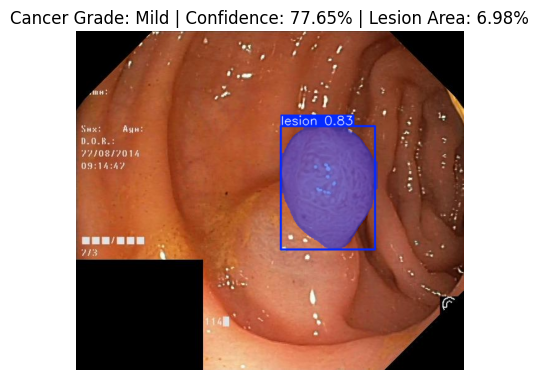


========== FINAL REPORT ==========
Cancer Detected      : YES
Cancer Grade         : Mild
Classification Score : 77.65%
Lesion Area          : 6.98%


In [8]:
analyze_cancer(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\yolo_seg\images\train\1b12a789-d651-4c4e-a982-784984b87b61.jpg"
)


========== FINAL REPORT ==========
Cancer Detected : NO


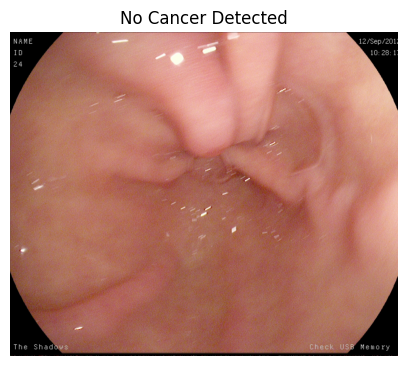

In [5]:
analyze_cancer(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\classification\test\normal\0b90e73c-e0aa-4bb1-96a5-8422d85b0457.jpg")


========== FINAL REPORT ==========
Cancer Detected : NO


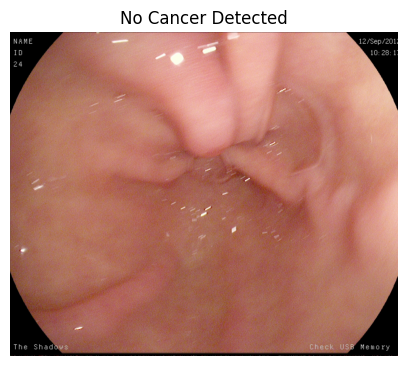

In [6]:
analyze_cancer(
    r"C:\Users\ADMIN\Desktop\Projects\Cancer Detection\Esophageal-Cancer-Detection\dataset\classification\test\normal\0b90e73c-e0aa-4bb1-96a5-8422d85b0457.jpg")